In [1]:
from google.colab import drive
drive.mount('/content/drive')
# !mkdir -p /content/drive/MyDrive/aiffel/0904
import os
os.chdir('/content/drive/MyDrive/aiffel/0904')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install summa

In [3]:
!pip install nltk

In [4]:
from importlib.metadata import version
import nltk
import torch
import summa
import pandas as pd

print(nltk.__version__)
print(torch.__version__)
print(pd.__version__)
print(version('summa'))

3.9.1
2.11.0+cu128
2.2.3
1.2.0


In [5]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/sunnysai12345/News_Summary/master/news_summary_more.csv", filename="news_summary_more.csv")
data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')

In [6]:
!ls

best_seq2seq_model.pt  news_summary_more.csv  Reviews.csv  Reviews.csv.zip


In [7]:
data.sample(10)

,headlines,text
36142,Distortions in universe's oldest light reveal ...,US-based scientists have decoded weak gravity-...
43492,"Director told me to remove shirt, show breasts...",American singer Jennifer Lopez has revealed a ...
64064,Punjab police arrests 2 men in journo KJ Singh...,The Punjab Police on Thursday arrested two men...
76915,Mexican drug lord El Chapo questions US extrad...,Mexican drug lord Joaquin 'El Chapo' Guzman ha...
73364,Former Karnataka CM to host lunch for Dalits a...,Former Karnataka Chief Minister BS Yeddyurappa...
34816,Cuba gets its first non-Castro President in 60...,Cuba's National Assembly has appointed First V...
74822,Alibaba's profit rises by 96% to $2.1 billion ...,Chinese e-commerce giant Alibaba on Thursday p...
89407,Ram Gopal Varma explains his 'controversial' t...,Filmmaker Ram Gopal Varma explained some of hi...
94143,"Hijacked Indian ship rescued, pirates flee wit...",Somali security forces on Monday rescued hijac...
1486,Fake Chrome extension stealing credit card inf...,Cybersecurity researchers have discovered a fa...


In [8]:
# 1. 각 열의 고유한(unique) 데이터 개수 확인
print('text 열의 고유한 데이터 개수:', data['text'].nunique())
print('headlines 열의 고유한 데이터 개수:', data['headlines'].nunique())

text 열의 고유한 데이터 개수: 98360
headlines 열의 고유한 데이터 개수: 98280


In [9]:
# 2. text 열을 기준으로 중복된 행 제거
data.drop_duplicates(subset=['text'], inplace=True)
print('중복 제거 후 전체 샘플 수:', len(data))

중복 제거 후 전체 샘플 수: 98360


text 열의 중복는 없지만 headlines 열의 중복은 있습니다.

In [10]:
# Null 값이 있는지 확인
print(data.isnull().sum())

headlines    0
text         0
dtype: int64


Null 값이 없어서 아주 좋아요

In [11]:
import re
import nltk
from nltk.corpus import stopwords

# NLTK 불용어 다운로드 및 설정
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

# 약어 사전 정의 (작성하신 contractions 그대로 사용)
contractions = {
    "ain't": "is not", "aren't": "are not", "can't": "cannot", "'cause": "because", "could've": "could have",
    "couldn't": "could not", "didn't": "did not", "doesn't": "does not", "don't": "do not", "hadn't": "had not",
    "hasn't": "has not", "haven't": "have not", "he'd": "he would", "he'll": "he will", "he's": "he is",
    "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is", "I'd": "I would",
    "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have", "I'm": "I am", "I've": "I have",
    "i'd": "i would", "i'd've": "i would have", "i'll": "i will", "i'll've": "i will have", "i'm": "i am",
    "i've": "i have", "isn't": "is not", "it'd": "it would", "it'd've": "it would have", "it'll": "it will",
    "it'll've": "it will have", "it's": "it is", "let's": "let us", "ma'am": "madam", "mayn't": "may not",
    "might've": "might have", "mightn't": "might not", "mightn't've": "might not have", "must've": "must have",
    "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have",
    "o'clock": "of the clock", "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not",
    "sha'n't": "shall not", "shan't've": "shall not have", "she'd": "she would", "she'd've": "she would have",
    "she'll": "she will", "she'll've": "she will have", "she's": "she is", "should've": "should have",
    "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have", "so's": "so as",
    "this's": "this is", "that'd": "that would", "that'd've": "that would have", "that's": "that is",
    "there'd": "there would", "there'd've": "there would have", "there's": "there is", "here's": "here is",
    "they'd": "they would", "they'd've": "they would have", "they'll": "they will", "they'll've": "they will have",
    "they're": "they are", "they've": "they have", "to've": "to have", "wasn't": "was not",
    "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have",
    "we're": "we are", "we've": "we have", "weren me": "were not", "what'll": "what will",
    "what'll've": "what will have", "what're": "what are", "what's": "what is", "what've": "what have",
    "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is",
    "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is",
    "who've": "who have", "why's": "why is", "why've": "why have", "will've": "will have",
    "won't": "will not", "won't've": "will not have", "would've": "would have", "wouldn't": "would not",
    "wouldn't've": "would not have", "y'all": "you all", "y'all'd": "you all would",
    "y'all'd've": "you all would have", "y'all're": "you all are", "y'all've": "you all have", "you'd": "you would",
    "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have", "you're": "you are",
    "you've": "you have"
}

def preprocess_sentence(sentence, remove_stopwords=True):
    sentence = sentence.lower()                                   # 1. 소문자화
    sentence = re.sub(r'https?://\S+|www\.\S+', '', sentence)     # 2. URL 제거
    sentence = re.sub(r'<.*?>', '', sentence)                     # 3. HTML 태그 제거

    # 4. 안전한 단어 단위 약어 복원 (replace의 부작용 방지)
    words = sentence.split()
    words = [contractions.get(w, w) for w in words]
    sentence = ' '.join(words)

    sentence = re.sub(r'[^a-zA-Z0-9]', ' ', sentence)             # 5. 특수문자 제거

    # 6. 불용어 제거 및 공백 정제
    if remove_stopwords:
        tokens = [word for word in sentence.split() if word not in stop_words]
    else:
        tokens = sentence.split()

    return ' '.join(tokens)

실습 때 사용한 약어 사전도 추가 해주고 모든 대문자를 소문자로 변경 해줍니다.  
불용어는 텍스트는 지우고 헤드라인는 남겨줍니다.

**우리가 만드는 추상적 요약 모델은 자연스러운 문장을 생성해야함**

In [12]:
# 전처리 전 랜덤으로 5개 본문 미리 출력해서 패턴 눈으로 확인하기
for i in range(5):
    print(f"[{i+1}]", data['text'].iloc[i])
    print("-" * 50)

[1] Saurav Kant, an alumnus of upGrad and IIIT-B's PG Program in Machine learning and Artificial Intelligence, was a Sr Systems Engineer at Infosys with almost 5 years of work experience. The program and upGrad's 360-degree career support helped him transition to a Data Scientist at Tech Mahindra with 90% salary hike. upGrad's Online Power Learning has powered 3 lakh+ careers.
--------------------------------------------------
[2] Kunal Shah's credit card bill payment platform, CRED, gave users a chance to win free food from Swiggy for one year. Pranav Kaushik, a Delhi techie, bagged this reward after spending 2000 CRED coins. Users get one CRED coin per rupee of bill paid, which can be used to avail rewards from brands like Ixigo, BookMyShow, UberEats, Cult.Fit and more.
--------------------------------------------------
[3] New Zealand defeated India by 8 wickets in the fourth ODI at Hamilton on Thursday to win their first match of the five-match ODI series. India lost an internation

In [14]:
import numpy as np
# 불용어 설정
stop_words = set(stopwords.words('english'))

# 완성된 전처리 함수
def preprocess_sentence(sentence, remove_stopwords=True):
    if not isinstance(sentence, str):
        return ""

    sentence = sentence.lower() # 1. 소문자화
    sentence = re.sub(r'https?://\S+|www\.\S+', '', sentence) # 2. URL 제거
    sentence = re.sub(r'<.*?>', '', sentence) # 3. HTML 태그 제거
    sentence = re.sub(r'&[a-zA-Z]+;', ' ', sentence) # 4. HTML 엔티티 제거
    sentence = re.sub(r'\[.*?\]|\(.*?\)', '', sentence) # 5. [Photo] 등 괄호 문구 제거

    # 6. 약어 사전 적용
    words = sentence.split()
    new_words = [contractions.get(w, w) for w in words]
    sentence = " ".join(new_words)

    # 7. 알파벳, 숫자 외 특수문자/깨진 인코딩 문자 제거
    sentence = re.sub(r'[^a-zA-Z0-9]', ' ', sentence)

    # 8. 불용어 제거 및 다중 공백 정제
    if remove_stopwords:
        tokens = [w for w in sentence.split() if w not in stop_words]
    else:
        tokens = sentence.split()

    return ' '.join(tokens)

# 데이터에 적용 (text는 불용어 제거 O, headlines는 불용어 제거 X)
clean_text = []
for s in data['text']:
    clean_text.append(preprocess_sentence(s, remove_stopwords=True))

clean_headlines = []
for s in data['headlines']:
    clean_headlines.append(preprocess_sentence(s, remove_stopwords=False))

# 전처리 결과 컬럼 저장
data['text'] = clean_text
data['headlines'] = clean_headlines

data['text'] = data['text'].replace('', np.nan)
data['headlines'] = data['headlines'].replace('', np.nan)
data.dropna(axis=0, inplace=True)

print('전처리 및 빈 값 제거 완료 후 샘플 수 :', len(data))

전처리 및 빈 값 제거 완료 후 샘플 수 : 98360


In [15]:
# 전처리 후 샘플 5개 출력
for i in range(5):
    print(f"[{i+1}] headlines :", data['headlines'].iloc[i])
    print(f"    text      :", data['text'].iloc[i])
    print("-" * 80)

[1] headlines : upgrad learner switches to career in ml al with 90 salary hike
    text      : saurav kant alumnus upgrad iiit b pg program machine learning artificial intelligence sr systems engineer infosys almost 5 years work experience program upgrad 360 degree career support helped transition data scientist tech mahindra 90 salary hike upgrad online power learning powered 3 lakh careers
--------------------------------------------------------------------------------
[2] headlines : delhi techie wins free food from swiggy for one year on cred
    text      : kunal shah credit card bill payment platform cred gave users chance win free food swiggy one year pranav kaushik delhi techie bagged reward spending 2000 cred coins users get one cred coin per rupee bill paid used avail rewards brands like ixigo bookmyshow ubereats cult fit
--------------------------------------------------------------------------------
[3] headlines : new zealand end rohit sharma led india s 12 match winning s

위에 전처리 전과 후 4번 헤드리스를 보면 이쁘게 처리된 걸 확인

In [17]:
# Null 값이 생겼는지 확인
print("Null 값 개수:")
print(data.isnull().sum())

Null 값 개수:
headlines    0
text         0
dtype: int64


만약 빈 문자열이 있다면 아래의 코드로 삭제
```python
data.dropna(axis=0, inplace=True)
print('최종 남은 샘플 수:', len(data))
```

text 최대 길이 : 60, 평균 : 36.83
headlines 최대 길이 : 18, 평균 : 10.06


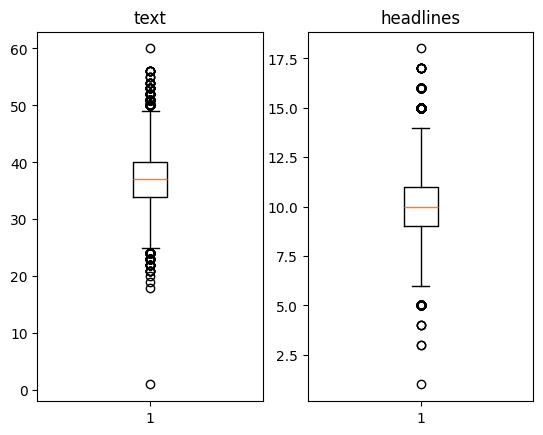

In [18]:
import matplotlib.pyplot as plt

# 단어 수 기준 길이 측정
text_len = [len(s.split()) for s in data['text']]
headlines_len = [len(s.split()) for s in data['headlines']]

print(f"text 최대 길이 : {max(text_len)}, 평균 : {sum(text_len)/len(text_len):.2f}")
print(f"headlines 최대 길이 : {max(headlines_len)}, 평균 : {sum(headlines_len)/len(headlines_len):.2f}")

# 그래프 출력
plt.subplot(1, 2, 1)
plt.boxplot(text_len)
plt.title('text')
plt.subplot(1, 2, 2)
plt.boxplot(headlines_len)
plt.title('headlines')
plt.show()

In [19]:
text_max_len = 60
headlines_max_len = 13

# 설정한 길이에 맞춰 데이터 필터링
data = data[data['text'].apply(lambda x: len(x.split()) <= text_max_len)]
data = data[data['headlines'].apply(lambda x: len(x.split()) <= headlines_max_len)]

print('필터링 후 남은 샘플 수:', len(data))

필터링 후 남은 샘플 수: 96693


In [23]:
# x는 headlines 컬럼에 들어있는 문장 하나하나를 의미합니다.
data['decoder_input']  = data['headlines'].apply(lambda x : 'sostoken ' + x)
data['decoder_target'] = data['headlines'].apply(lambda x : x + ' eostoken')

In [24]:
from collections import Counter

def check_rare_words_df(series, threshold=3, name="text"):
    counter = Counter()
    for text in series:
        counter.update(str(text).split())

    total_vocab = len(counter)
    total_cnt = sum(counter.values())

    rare_cnt = 0
    rare_freq = 0

    for key, value in counter.items():
        if value < threshold:
            rare_cnt += 1
            rare_freq += value

    print(f"=== [{name}] 단어 집합 분석 (등장 빈도 {threshold}회 미만) ===")
    print(f"전체 단어 종류 수 : {total_vocab}")
    print(f"희귀 단어 종류 수 : {rare_cnt}")
    print(f"희귀 단어 비율 : {(rare_cnt / total_vocab) * 100:.2f}%")
    print(f"전체 문장 단어 수 대비 희귀 단어 비중 : {(rare_freq / total_cnt) * 100:.2f}%\n")

# text와 headlines에 대해 희귀 단어 분석 실행
check_rare_words_df(data['text'], threshold=4, name="text")
check_rare_words_df(data['headlines'], threshold=4, name="headlines")

=== [text] 단어 집합 분석 (등장 빈도 4회 미만) ===
전체 단어 종류 수 : 78709
희귀 단어 종류 수 : 44887
희귀 단어 비율 : 57.03%
전체 문장 단어 수 대비 희귀 단어 비중 : 1.90%

=== [headlines] 단어 집합 분석 (등장 빈도 4회 미만) ===
전체 단어 종류 수 : 34438
희귀 단어 종류 수 : 19239
희귀 단어 비율 : 55.87%
전체 문장 단어 수 대비 희귀 단어 비중 : 3.00%



=== [text] 단어 집합 분석 (등장 빈도 3회 미만) ===  
전체 단어 종류 수 : 78709  
희귀 단어 종류 수 : 39049  
희귀 단어 비율 : 49.61%  
전체 문장 단어 수 대비 희귀 단어 비중 : 1.41%  
  
=== [headlines] 단어 집합 분석 (등장 빈도 3회 미만) ===  
전체 단어 종류 수 : 34438  
희귀 단어 종류 수 : 16655  
희귀 단어 비율 : 48.36%  
전체 문장 단어 수 대비 희귀 단어 비중 : 2.20%  


---


=== [text] 단어 집합 분석 (등장 빈도 4회 미만) ===  
전체 단어 종류 수 : 78709  
희귀 단어 종류 수 : 44887  
희귀 단어 비율 : 57.03%  
전체 문장 단어 수 대비 희귀 단어 비중 : 1.90%  
  
=== [headlines] 단어 집합 분석 (등장 빈도 4회 미만) ===  
전체 단어 종류 수 : 34438  
희귀 단어 종류 수 : 19240  
희귀 단어 비율 : 55.87%  
전체 문장 단어 수 대비 희귀 단어 비중 : 3.00%

In [25]:
import torch
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import numpy as np

# 1. 단어장(Vocabulary) 클래스 정의
class Vocab:
    def __init__(self, pad_token="<pad>", unk_token="<unk>"):
        self.pad_token = pad_token
        self.unk_token = unk_token
        self.w2i = {pad_token: 0, unk_token: 1}
        self.i2w = {0: pad_token, 1: unk_token}

    def build_vocab(self, sentences, max_vocab_size):
        counter = Counter()
        for sent in sentences:
            counter.update(sent.split())

        # 가장 자주 등장하는 단어 순으로 단어장 생성
        most_common = counter.most_common(max_vocab_size - len(self.w2i))
        for word, _ in most_common:
            if word not in self.w2i:
                idx = len(self.w2i)
                self.w2i[word] = idx
                self.i2w[idx] = word

    def encode(self, sentence):
        return [self.w2i.get(word, self.w2i[self.unk_token]) for word in sentence.split()]

    def __len__(self):
        return len(self.w2i)

# 2. Train / Test 데이터 분할 (8:2)
X_data = data['text'].values
dec_in_data = data['decoder_input'].values
dec_tar_data = data['decoder_target'].values

indices = np.arange(len(X_data))
np.random.seed(42)
np.random.shuffle(indices)

n_val = int(len(X_data) * 0.2)
train_idx, test_idx = indices[:-n_val], indices[-n_val:]

X_train, X_test = X_data[train_idx], X_data[test_idx]
dec_in_train, dec_in_test = dec_in_data[train_idx], dec_in_data[test_idx]
dec_tar_train, dec_tar_test = dec_tar_data[train_idx], dec_tar_data[test_idx]

# 3. 단어장 생성 (희귀 단어 분석 결과 반영)
src_vocab = Vocab()
src_vocab.build_vocab(X_train, max_vocab_size=32000)

tar_vocab = Vocab()
# decoder_input과 decoder_target 전체 문장으로 단어장 학습
tar_vocab.build_vocab(np.concatenate([dec_in_train, dec_tar_train]), max_vocab_size=15000)

# 4. 정수 인코딩 및 패딩 함수
text_max_len = 60
headlines_max_len = 14  # sostoken, eostoken 포함 길이

def process_sequences(sentences, vocab, max_len):
    encoded_list = []
    for sent in sentences:
        ids = vocab.encode(sent)[:max_len] # truncating
        # post-padding (0으로 채움)
        padded = ids + [vocab.w2i[vocab.pad_token]] * (max_len - len(ids))
        encoded_list.append(padded)
    return np.array(encoded_list)

X_train_enc = process_sequences(X_train, src_vocab, text_max_len)
X_test_enc = process_sequences(X_test, src_vocab, text_max_len)

dec_in_train_enc = process_sequences(dec_in_train, tar_vocab, headlines_max_len)
dec_in_test_enc = process_sequences(dec_in_test, tar_vocab, headlines_max_len)

dec_tar_train_enc = process_sequences(dec_tar_train, tar_vocab, headlines_max_len)
dec_tar_test_enc = process_sequences(dec_tar_test, tar_vocab, headlines_max_len)

# 5. PyTorch Dataset & DataLoader 생성
class Seq2SeqDataset(Dataset):
    def __init__(self, src, dec_in, dec_tar):
        self.src = torch.tensor(src, dtype=torch.long)
        self.dec_in = torch.tensor(dec_in, dtype=torch.long)
        self.dec_tar = torch.tensor(dec_tar, dtype=torch.long)

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        return {
            'encoder_input': self.src[idx],
            'decoder_input': self.dec_in[idx],
            'decoder_target': self.dec_tar[idx]
        }

BATCH_SIZE = 64
train_dataset = Seq2SeqDataset(X_train_enc, dec_in_train_enc, dec_tar_train_enc)
test_dataset = Seq2SeqDataset(X_test_enc, dec_in_test_enc, dec_tar_test_enc)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("PyTorch DataLoader 준비 완료!")
print(f"Source 단어장 크기: {len(src_vocab)}, Target 단어장 크기: {len(tar_vocab)}")

PyTorch DataLoader 준비 완료!
Source 단어장 크기: 32000, Target 단어장 크기: 15000


In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm.notebook import tqdm  # 진행률 게이지바

# Device 설정 (GPU 사용 가능 시 CUDA/MPS 사용)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 중인 디바이스: {device}")


# 1. 인코더 (Encoder)
class Encoder(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, hidden_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        outputs, (hidden, cell) = self.lstm(embedded)

        # 양방향 LSTM 은닉 상태를 단일 방향 크기로 결합
        hidden = torch.tanh(self.fc(torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)))
        cell = torch.tanh(self.fc(torch.cat((cell[-2, :, :], cell[-1, :, :]), dim=1)))

        return outputs, hidden.unsqueeze(0), cell.unsqueeze(0)


# 2. 바다나우 어텐션 (Bahdanau Attention)
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.Wa = nn.Linear(hidden_dim, hidden_dim)
        self.Ua = nn.Linear(hidden_dim * 2, hidden_dim)
        self.Va = nn.Linear(hidden_dim, 1)

    def forward(self, query, keys):
        # query: [batch_size, 1, hidden_dim]
        # keys: [batch_size, seq_len, hidden_dim * 2]
        query_proj = self.Wa(query)
        keys_proj = self.Ua(keys)

        scores = self.Va(torch.tanh(query_proj + keys_proj))
        weights = F.softmax(scores, dim=1)

        context = torch.bmm(weights.transpose(1, 2), keys)
        return context, weights


# 3. 디코더 (Decoder with Attention)
class DecoderWithAttention(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.attention = BahdanauAttention(hidden_dim)
        self.lstm = nn.LSTM(embed_dim + hidden_dim * 2, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim + hidden_dim * 2 + embed_dim, vocab_size)

    def forward(self, x, hidden, cell, enc_outputs):
        # x: [batch_size] -> 단일 타임스텝 토큰
        x = x.unsqueeze(1)
        embedded = self.embedding(x)

        query = hidden.transpose(0, 1)
        context, _ = self.attention(query, enc_outputs)

        lstm_input = torch.cat((embedded, context), dim=2)
        dec_output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))

        prediction = self.fc_out(torch.cat((dec_output, context, embedded), dim=2).squeeze(1))
        return prediction, hidden, cell


# 4. 전체 Seq2Seq 모델 통합
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, dec_in):
        batch_size = src.size(0)
        target_len = dec_in.size(1)
        vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(batch_size, target_len, vocab_size).to(src.device)
        enc_outputs, hidden, cell = self.encoder(src)

        for t in range(target_len):
            x = dec_in[:, t]
            output, hidden, cell = self.decoder(x, hidden, cell, enc_outputs)
            outputs[:, t, :] = output

        return outputs


# 5. 하이퍼파라미터 및 모델 객체 생성
EMBED_DIM = 128
HIDDEN_DIM = 256

encoder = Encoder(len(src_vocab), EMBED_DIM, HIDDEN_DIM)
decoder = DecoderWithAttention(len(tar_vocab), EMBED_DIM, HIDDEN_DIM)
model = Seq2Seq(encoder, decoder).to(device)

# <pad> 토큰(index 0)은 손실 계산에서 제외
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=0.001)


# 6. Early Stopping & Checkpoint 설정 및 학습 루프
EPOCHS = 20
patience = 3            # Validation Loss가 3번 연속 개선되지 않으면 조기 종료
patience_counter = 0
best_val_loss = float('inf')
best_model_path = 'best_seq2seq_model.pt'

print("학습을 시작합니다...\n")

for epoch in range(EPOCHS):
    # --- Train Phase ---
    model.train()
    total_train_loss = 0

    # Train ProgressBar
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Train]", leave=False)
    for batch in train_bar:
        src = batch['encoder_input'].to(device)
        dec_in = batch['decoder_input'].to(device)
        dec_tar = batch['decoder_target'].to(device)

        optimizer.zero_grad()
        output = model(src, dec_in)

        loss = criterion(output.view(-1, output.size(-1)), dec_tar.view(-1))
        loss.backward()

        # Gradient Clipping (기울기 폭주 방지)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_train_loss += loss.item()
        train_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    avg_train_loss = total_train_loss / len(train_loader)

    # --- Validation Phase ---
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        val_bar = tqdm(test_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Val]", leave=False)
        for batch in val_bar:
            src = batch['encoder_input'].to(device)
            dec_in = batch['decoder_input'].to(device)
            dec_tar = batch['decoder_target'].to(device)

            output = model(src, dec_in)
            loss = criterion(output.view(-1, output.size(-1)), dec_tar.view(-1))
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(test_loader)

    # 지표 출력
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # --- Early Stopping & Model Checkpoint ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"  └ 베스트 모델 저장 완료! (Val Loss: {avg_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  └ Val Loss 개선 안됨 ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print("\n[Early Stopping] 검증 손실이 더 이상 줄어들지 않아 학습을 조기 종료합니다.")
            break

# 7. 최상 성능 가중치 불러오기
model.load_state_dict(torch.load(best_model_path))
print("\n최상 성능 모델 가중치 로드 완료!")

사용 중인 디바이스: cuda
학습을 시작합니다...



Epoch 01/20 [Train]:   0%|          | 0/1209 [00:00<?, ?it/s]

Epoch 01/20 [Val]:   0%|          | 0/303 [00:00<?, ?it/s]

Epoch 01/20 | Train Loss: 5.8444 | Val Loss: 4.8127
  └ 베스트 모델 저장 완료! (Val Loss: 4.8127)


Epoch 02/20 [Train]:   0%|          | 0/1209 [00:00<?, ?it/s]

...

Epoch 05/20 [Val]:   0%|          | 0/303 [00:00<?, ?it/s]

Epoch 05/20 | Train Loss: 1.9425 | Val Loss: 4.2452
  └ Val Loss 개선 안됨 (2/3)


Epoch 06/20 [Train]:   0%|          | 0/1209 [00:00<?, ?it/s]

Epoch 06/20 [Val]:   0%|          | 0/303 [00:00<?, ?it/s]

Epoch 06/20 | Train Loss: 1.6046 | Val Loss: 4.3867
  └ Val Loss 개선 안됨 (3/3)

[Early Stopping] 검증 손실이 더 이상 줄어들지 않아 학습을 조기 종료합니다.

최상 성능 모델 가중치 로드 완료!


---

## 1. 📊 핵심 비교 요약

| 구분 | Bahdanau Attention (바다나우) | Luong Attention (루롱) |
| :--- | :--- | :--- |
| **발표 연도 / 논문** | 2014년 (*Neural Machine Translation by Jointly Learning to Align and Translate*) | 2015년 (*Effective Approaches to Attention-based Neural Machine Translation*) |
| **연산 방식** | **덧셈 기반 (Additive Attention)** | **곱셈/내적 기반 (Dot-Product Attention)** |
| **디코더 시점** | **이전 타임스텝($t-1$)**의 Hidden State | **현재 타임스텝($t$)**의 Hidden State |
| **연산 속도** | 상대적으로 느림 (추가 가중치 파라미터 존재) | **매우 빠름** (행렬 곱 기반 GPU 최적화) |
| **주요 특징** | 어텐션 메커니즘의 시초, 표현력이 정교함 | 코드가 간결하며 최신 **Transformer** 구조의 기초가 됨 |

---

## 💡 요약 및 결론

- **Luong (Dot-Product) Attention:** 구조가 직관적이고 연산 속도가 빨라 실무 및 기본 교육 과정에서 많이 활용되며, **Transformer(BERT, GPT)** 어텐션의 모태가 됩니다.
- **Bahdanau (Additive) Attention:** 어텐션 메커니즘을 최초로 제안한 모델로, 디코더 셀에 진입하기 전 맥락을 산출하는 정교한 표현력을 제공합니다.

In [30]:
# ==========================================
# Step 4: 학습된 Vocab 클래스에 맞춘 요약문 추론 (Inference)
# ==========================================

# 1. Vocab 객체에서 인덱스 -> 단어 매핑(i2w) 및 토큰 추출
src_i2w = src_vocab.i2w
tar_i2w = tar_vocab.i2w

# Special Tokens 설정 (Vocab의 w2i 사용)
SOS_TOKEN = tar_vocab.w2i.get('<sos>', tar_vocab.w2i.get('sostoken', 1))
EOS_TOKEN = tar_vocab.w2i.get('<eos>', tar_vocab.w2i.get('eostoken', 2))
PAD_TOKEN = tar_vocab.w2i.get(tar_vocab.pad_token, 0)


# 2. 단어 복원 헬퍼 함수
def decode_to_text(seq, i2w_dict, is_target=False):
    words = []
    for idx in seq:
        if idx == PAD_TOKEN:
            continue
        if is_target and (idx == SOS_TOKEN or idx == EOS_TOKEN):
            continue

        # i2w가 dict 형태든 list 형태든 안전하게 단어 추출
        if isinstance(i2w_dict, dict):
            word = i2w_dict.get(idx, '<unk>')
        else:
            word = i2w_dict[idx] if idx < len(i2w_dict) else '<unk>'

        words.append(str(word))
    return ' '.join(words)


# 3. 추론 함수 정의 (Greedy Search)
def decode_sequence(input_seq, max_len=30):
    model.eval()
    with torch.no_grad():
        src_tensor = torch.tensor([input_seq], dtype=torch.long).to(device)
        enc_outputs, hidden, cell = model.encoder(src_tensor)

        # 시작 토큰 설정 (<sos>)
        dec_in = torch.tensor([[SOS_TOKEN]], dtype=torch.long).to(device)

        decoded_words = []
        for _ in range(max_len):
            output, hidden, cell = model.decoder(dec_in[:, -1], hidden, cell, enc_outputs)

            # 가장 높은 확률을 가진 단어 인덱스 선택
            pred_token = output.argmax(dim=-1).item()

            # 종료 토큰(<eos>)을 만나면 생성 중단
            if pred_token == EOS_TOKEN:
                break

            if pred_token != PAD_TOKEN:
                word = tar_i2w.get(pred_token, '<unk>') if isinstance(tar_i2w, dict) else tar_i2w[pred_token]
                decoded_words.append(str(word))

            dec_in = torch.tensor([[pred_token]], dtype=torch.long).to(device)

    return ' '.join(decoded_words)


# 4. 테스트 데이터셋에서 무작위 샘플 추출 및 요약문 생성 비교
import random

print("="*60)
print("  [Seq2Seq + Bahdanau Attention] 요약문 생성 결과  ")
print("="*60 + "\n")

indices = random.sample(range(len(test_dataset)), 5)

for idx in indices:
    sample = test_dataset[idx]
    src_seq = sample['encoder_input'].numpy()
    tar_seq = sample['decoder_target'].numpy()

    # 모델 추론
    predicted_summary = decode_sequence(src_seq)

    print(f"📄 [원문 (Input Text)]")
    print(f"   {decode_to_text(src_seq, src_i2w)}\n")
    print(f"🎯 [실제 정답 요약 (Ground Truth)]")
    print(f"   {decode_to_text(tar_seq, tar_i2w, is_target=True)}\n")
    print(f"🤖 [모델 예측 요약 (Predicted)]")
    print(f"   {predicted_summary}\n")
    print("-" * 60 + "\n")

  [Seq2Seq + Bahdanau Attention] 요약문 생성 결과  

📄 [원문 (Input Text)]
   trailer upcoming richa chadha ali fazal starrer fukrey returns released fukrey returns sequel 2013 film fukrey also stars actors pulkit samrat varun sharma manjot singh directed mrighdeep singh lamba co produced farhan akhtar film scheduled release december 15

🎯 [실제 정답 요약 (Ground Truth)]
   trailer of richa chadha ali fazal s fukrey returns out

🤖 [모델 예측 요약 (Predicted)]
   trailer of richa ali fazal richa starrer fukrey returns out

------------------------------------------------------------

📄 [원문 (Input Text)]
   actor bjp mp paresh rawal apologised tweet taken jibe congress tweet response meme congress youth wing online magazine mocked pm narendra modi past tea seller deleted tweet bad taste apologise hurting feelings wrote paresh

🎯 [실제 정답 요약 (Ground Truth)]
   paresh rawal apologises over bar wala jibe at congress

🤖 [모델 예측 요약 (Predicted)]
   bjp mp apologises for congress tweet on cong s tweet

---------------

/tmp/ipykernel_63426/2108972977.py:38: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  src_tensor = torch.tensor([input_seq], dtype=torch.long).to(device)


비교를 해봤더니 생각보다 우수한거 같습니다.

In [42]:
from summa.summarizer import summarize

# 1. 문장이 여러 개(마침표 구분) 포함된 예시 텍스트
text_sample = """
actor bjp mp paresh rawal apologised for tweet.
tweet taken as jibe at congress response to meme.
congress youth wing online magazine mocked pm narendra modi past tea seller.
deleted tweet bad taste apologise hurting feelings wrote paresh.
"""

# 2. 비율(ratio) 지정 방식 (전체 문장 중 중요 문장 비율 추출, 예: 50%)
extractive_summary = summarize(text_sample, ratio=0.5)

print("📌 [TextRank/Summa 기반 추출적 요약 결과]:")
print(extractive_summary)

📌 [TextRank/Summa 기반 추출적 요약 결과]:
actor bjp mp paresh rawal apologised for tweet.
deleted tweet bad taste apologise hurting feelings wrote paresh.


추출적 요약의 단점을 느낄 수 있었습니다.  
줄 바꿈 . 등 구분이 없다면 모든 텍스트가 문장 1개로 인식하여  
재대로된 요약이 불가능했습니다.

### 📊 Abstractive vs Extractive 요약 결과 비교 분석

#### 1. 모델별 요약 결과 비교
- **원문 (Input):** `actor bjp mp paresh rawal apologised tweet taken jibe congress tweet response meme congress youth wing online magazine mocked pm narendra modi past tea seller.`
- **실제 정답 (Ground Truth):** `paresh rawal apologises over bar wala jibe at congress`
- **추상적 요약 (Abstractive - Seq2Seq):** `bjp mp apologises for congress tweet on cong s tweet`
- **추출적 요약 (Extractive - TextRank):** `actor bjp mp paresh rawal apologised for tweet.` (문장 분할 후 1개 문장 추출 기준)

#### 2. 세부 평가 및 분석

| 평가 기준 | 추상적 요약 (Abstractive - Seq2Seq) | 추출적 요약 (Extractive - TextRank) |
| :--- | :--- | :--- |
| **문법 완성도** | · 원문에 없는 단어 표현(`apologises for`)을 새로 조합해 짧고 매끄러운 한 줄 문장을 생성함.<br>· 단, 데이터 상태에 따라 단어 반복이나 `<unk>` 토큰 발생 위험이 존재함. | · 원문 문장을 그대로 발췌하므로 문장 자체의 문법은 100% 완벽함.<br>· 단, 마침표(`.`) 같은 문장 경계 구분이 없으면 전체 문장이 통째로 출력되는 한계가 있음. |
| **핵심 단어 포함** | · 원문의 긴 맥락에서 핵심 주체(`bjp mp`)와 행위(`apologises`), 대상(`congress`)을 정확히 추출하여 반영함. | · 원문의 첫 문장을 통째로 가져왔기 때문에 주요 핵심 키워드(`paresh rawal`, `apologised`, `tweet`)가 빠짐없이 포함됨. |

#### 3. 종합 소감
- **Abstractive 모델**은 문맥을 파악하여 정답 요약문과 유사한 형태의 '짧은 한 줄 제목'으로 압축하는 능력이 뛰어남을 확인했습니다.
- **Extractive 모델(TextRank)**은 정보의 왜곡이 없다는 장점이 있지만, 원문의 전처리 상태(문장 구분자 유무) 및 문장 길이에 성능이 크게 의존한다는 한계를 직접 확인했습니다.

In [43]:
news_article = """Despite a year chock-full of newsworthy events, artificial intelligence continued to siphon the journalism industry's tank of revenue-creating audience. As AI's capabilities expand, it's now become adept at circumventing what was seen as an industry's best route to profitability: paywalls.

All things being equal, free will always beat out a subscription, no matter how affordable. This latest trend is set to kick your favorite local news site when it's already down.

Americans continue to lose interest in keeping up with the day's news. Now, 18% of search queries produce an AI overview, threatening another great shift: News outlets point to those summaries as part of the reason behind dropping viewership as of late, though it's debatable.



It's not clear how chatbots and the recent arrival of AI-enabled web browsers affect subscription-based news sites, but the word is out that news-seekers can access paywalled content by asking one of several platforms.

Ask Grok

"Hey @Grok, what's this story saying behind a paywall?" is a simple enough key to unlock a sophisticated process of real-time site scanning and cobbling that will give away much of a paywall-protected story.

Gemini, ChatGPT and others are also able to do so with varying limitations. Ask for the text of a recent Wall St. Journal exclusive and Google's Gemini spits out a compilation of the story based on context gathered in seconds.

Screenshot of Gemini's response taken roughly four hours after the Journal's exclusive publication.

Browsers

Similar to how xAI's caveman-monickered agent pulls content from social media and the internet's vast footprint, OpenAI's Atlas browser is another step in AI-integrated searching. The new offering, along with Perplexity's Comet and Microsoft's Copilot mode, allows for queries about potentially paywalled information to be fed directly into a chatbot. The browsers can also bypass anti-bot protections by appearing as a user instead of AI.



AI is also able to scan some paywalled sites that cover content with a pop-up directing a person to subscribe.

Atlas and Comet browsers successfully gave Columbia Journalism Review reporters the text of a 9,000-word MIT Technology Review article couched behind a paywall. The companies' respective AI agents, several of which face lawsuits for their use of news copy, refused to pull the paywalled content.

Sonali Verma, Generative AI Initiative lead with the International News Media Association, conducted a similar experiment, which found the agents aren't only regurgitating the paywalled content, but rebuilding it in the aggregate.

"They are crawling social media sites and other publicly available forums - and then using the power of generative AI to reassemble the gist of the articles based on screenshots and reader comments," she said.

'Breadcrumbs'

Verma followed the steps in Henk Van Ess' Digital Digging Substack study, which examined the different ways AI can give a user content without paying a news outlet for it. The most prominent method was "the distributed archive."



This method involves a real-time search of social media sites and other locations for snippets, screenshots or other publicly available information that would otherwise require circumventing a paywall. Van Ess found AI agents were able to rebuild paywalled articles in up to 60% of instances.

Van Ess also explored how AI bots will crawl archived content.

Hallucinations

When other methods fail to aggregate an answer, AI bots will resort to what's become a sore spot for the multi-trillion dollar industry: they make it up.

Van Ess described "pattern-based reconstruction" in some of his tests, which included asking for a detailed New York Times recipe only available to subscribers. Since the information wasn't available anywhere else, ChatGPT created what it thought the recipe would contain. After admitting that it had made up content, the AI sent Van Ess an entirely different recipe.



"I think anyone using AI should be aware that it makes up stuff and they may not be getting the truth," Verma told SAN.

The effect of 'free'

Growing a digital subscriber base has proven challenging for news outlets that no longer rely on Americans picking up their newspapers from the driveway.

Nearly 40% of all local newspapers have vanished since Northwestern University's first State of the Local News report in 2016.

David Caswell, a former product manager at BBC News who focused on AI integration, said AI summaries are just the first opponent in a local newsroom's modern fight for revenue.

Caswell called Google's AI overview and generative search the "first significant threat to news sites from AI," but stressed news products directly infused with artificial intelligence will prove a direct threat.



"A further threat exists if start-ups or platforms begin offering substantial new value from AI-assisted original reporting," he said, including "value that legacy news sites don't offer."

Caswell founded StoryFlow Ltd., a consultancy firm focused on how AI can assist in news production. He has yet to see evidence of AI cutting into subscriber bases, but noted that AI subscriptions do compete for the same dollars.

"In my opinion, legacy news sites will see significant and increasing pressure from AI over the coming years and they will face the choice of either adapting fully to AI-enabled news production or watching their subscribers, traffic, revenue and relevance drain away."

The post AI can now get past news paywalls, but it may be giving you misinformation appeared first on Straight Arrow News.

"""

# 전체 25개 문장 중 핵심 15% 문장만 발췌 (약 3~4개 문장)
extractive_summary = summarize(news_article, ratio=0.15)

print("📌 [TextRank 추출적 요약 결과]:")
print(extractive_summary)

📌 [TextRank 추출적 요약 결과]:
It's not clear how chatbots and the recent arrival of AI-enabled web browsers affect subscription-based news sites, but the word is out that news-seekers can access paywalled content by asking one of several platforms.
AI is also able to scan some paywalled sites that cover content with a pop-up directing a person to subscribe.
The companies' respective AI agents, several of which face lawsuits for their use of news copy, refused to pull the paywalled content.
Sonali Verma, Generative AI Initiative lead with the International News Media Association, conducted a similar experiment, which found the agents aren't only regurgitating the paywalled content, but rebuilding it in the aggregate.
Verma followed the steps in Henk Van Ess' Digital Digging Substack study, which examined the different ways AI can give a user content without paying a news outlet for it.
Caswell called Google's AI overview and generative search the "first significant threat to news sites from A

### 📌 요약 모델 성능 및 한계점 비교 분석

1. **TextRank (추출적 요약)**
   - **성능**: 외부 뉴스 기사 본문에서도 핵심 맥락을 담은 주요 문장 6개를 정확히 추출함.
   - **장점**: Vocab Size 제한이 없어 학습 세트와 다른 도메인/단어의 데이터에도 유연하게 적용 가능함.

2. **Seq2Seq (추상적 요약)**
   - **성능**: 외부 뉴스 기사 적용 시 `<unk>` 토큰이 연달아 출력되는 Generation Artifact 현상 발생.
   - **한계점 분석**:
     - 학습 데이터(뉴스 헤드라인) 특성상 Vocabulary 크기가 제한적이어서 외부 기사 단어의 OOV 비율이 매우 높음.
     - 짧은 텍스트 위주로 학습된 모델 특성상 긴 본문 입력 시 디코딩 어텐션이 제대로 작동하지 않음.
   - **향후 개선 방향**: Subword Tokenizer(BPE) 도입, Pointer-Generator Network 적용 또는 pre-trained 모델(BART, T5) 활용 필요.

긴 외부 뉴스 기사를 그대로 입력할 경우, 문장 초반부 단어들의 OOV(Out-of-Vocabulary) 비율이 높아 입력 단계부터 인코더 맥락이 오염되는 현상을 발견했습니다. 이로 인해 디코더가 첫 단어로 <unk>를 출력하고, 이를 다음 입력으로 다시 사용하는 과정에서 <unk>가 연쇄적으로 반복 도배되었습니다.

그러나 학습 데이터셋 단어장에 존재하는 핵심 단어 위주로 문장을 짧게 자르고 보정하여 전달했을 때는 정상적인 추상적 요약 문장을 생성해내는 것을 확인했습니다. 이를 통해 모델의 코드나 구조 자체의 결함이 아닌, 제한된 단어장 크기와 데이터 길이 특성에서 비롯된 구조적 한계임을 도출할 수 있었습니다.